# Leukemia Binary Classification Project

**Dataset:** `AugmentedImages` with two folders: `ALL` and `Healthy`  
**Architecture:** EfficientNetV2-S + ConvNeXt-Tiny with Feature Fusion  
**Task:** Binary classification: `Healthy` vs `ALL`  

This notebook follows the report pipeline: preprocessing, HSI contrast enhancement, transfer learning, deep feature extraction, feature fusion, classification, and evaluation.

In [1]:
# ==========================================
# 1. Imports + Device Setup
# ==========================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Optional: used for histogram equalization in HSI preprocessing
try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
    print("cv2 is not installed. HSI equalization will use a NumPy fallback.")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:
# ==========================================
# 2. Dataset Path Setup
# ==========================================

# Your dataset folder contains two class folders: ALL and Healthy
# Change this path only if your dataset location changes.
dataset_path = r"C:/Users/kadi9/OneDrive/Desktop/GP_project/data/datasets/ALL_IDB2 (2)/ALL_IDB2/img"


print("Dataset path:", dataset_path)
print("Exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    print("Folders:", os.listdir(dataset_path))
else:
    raise FileNotFoundError("Dataset path not found. Please check dataset_path.")


Dataset path: C:/Users/kadi9/OneDrive/Desktop/GP_project/data/datasets/ALL_IDB2 (2)/ALL_IDB2/img
Exists: True
Folders: ['Im001_1.tif', 'Im002_1.tif', 'Im003_1.tif', 'Im004_1.tif', 'Im005_1.tif', 'Im006_1.tif', 'Im007_1.tif', 'Im008_1.tif', 'Im009_1.tif', 'Im010_1.tif', 'Im011_1.tif', 'Im012_1.tif', 'Im013_1.tif', 'Im014_1.tif', 'Im015_1.tif', 'Im016_1.tif', 'Im017_1.tif', 'Im018_1.tif', 'Im019_1.tif', 'Im020_1.tif', 'Im021_1.tif', 'Im022_1.tif', 'Im023_1.tif', 'Im024_1.tif', 'Im025_1.tif', 'Im026_1.tif', 'Im027_1.tif', 'Im028_1.tif', 'Im029_1.tif', 'Im030_1.tif', 'Im031_1.tif', 'Im032_1.tif', 'Im033_1.tif', 'Im034_1.tif', 'Im035_1.tif', 'Im036_1.tif', 'Im037_1.tif', 'Im038_1.tif', 'Im039_1.tif', 'Im040_1.tif', 'Im041_1.tif', 'Im042_1.tif', 'Im043_1.tif', 'Im044_1.tif', 'Im045_1.tif', 'Im046_1.tif', 'Im047_1.tif', 'Im048_1.tif', 'Im049_1.tif', 'Im050_1.tif', 'Im051_1.tif', 'Im052_1.tif', 'Im053_1.tif', 'Im054_1.tif', 'Im055_1.tif', 'Im056_1.tif', 'Im057_1.tif', 'Im058_1.tif', 'Im059_1.t

In [3]:
# ==========================================
# 3. HSI Contrast Enhancement Functions
# ==========================================

# These functions implement the report preprocessing step:
# RGB -> HSI, equalize Intensity channel, then HSI -> RGB.

def rgb_to_hsi(rgb_img):
    """Convert RGB image in [0, 1] to HSI channels."""
    rgb = rgb_img.astype(np.float32)
    R, G, B = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]

    eps = 1e-8
    I = (R + G + B) / 3.0

    min_rgb = np.minimum(np.minimum(R, G), B)
    S = 1 - (3.0 / (R + G + B + eps)) * min_rgb
    S = np.clip(S, 0, 1)

    numerator = 0.5 * ((R - G) + (R - B))
    denominator = np.sqrt((R - G) ** 2 + (R - B) * (G - B)) + eps
    theta = np.arccos(np.clip(numerator / denominator, -1, 1))

    H = np.where(B <= G, theta, 2 * np.pi - theta)
    H = H / (2 * np.pi)

    return H, S, I


def hsi_to_rgb(H, S, I):
    """Convert HSI channels in [0, 1] back to RGB in [0, 1]."""
    H = H * 2 * np.pi
    R = np.zeros_like(H)
    G = np.zeros_like(H)
    B = np.zeros_like(H)
    eps = 1e-8

    # Sector 0: 0 <= H < 120
    idx = (H >= 0) & (H < 2 * np.pi / 3)
    B[idx] = I[idx] * (1 - S[idx])
    R[idx] = I[idx] * (1 + (S[idx] * np.cos(H[idx])) / (np.cos(np.pi / 3 - H[idx]) + eps))
    G[idx] = 3 * I[idx] - (R[idx] + B[idx])

    # Sector 1: 120 <= H < 240
    idx = (H >= 2 * np.pi / 3) & (H < 4 * np.pi / 3)
    H2 = H[idx] - 2 * np.pi / 3
    R[idx] = I[idx] * (1 - S[idx])
    G[idx] = I[idx] * (1 + (S[idx] * np.cos(H2)) / (np.cos(np.pi / 3 - H2) + eps))
    B[idx] = 3 * I[idx] - (R[idx] + G[idx])

    # Sector 2: 240 <= H < 360
    idx = (H >= 4 * np.pi / 3) & (H < 2 * np.pi)
    H3 = H[idx] - 4 * np.pi / 3
    G[idx] = I[idx] * (1 - S[idx])
    B[idx] = I[idx] * (1 + (S[idx] * np.cos(H3)) / (np.cos(np.pi / 3 - H3) + eps))
    R[idx] = 3 * I[idx] - (G[idx] + B[idx])

    rgb = np.stack([R, G, B], axis=-1)
    return np.clip(rgb, 0, 1)


def hsi_contrast_enhancement(pil_img):
    """Apply histogram equalization on the HSI Intensity channel."""
    img = pil_img.convert("RGB")
    rgb = np.asarray(img).astype(np.float32) / 255.0

    H, S, I = rgb_to_hsi(rgb)
    I_uint8 = np.clip(I * 255, 0, 255).astype(np.uint8)

    if CV2_AVAILABLE:
        I_eq = cv2.equalizeHist(I_uint8).astype(np.float32) / 255.0
    else:
        # NumPy fallback for histogram equalization
        hist, bins = np.histogram(I_uint8.flatten(), 256, [0, 256])
        cdf = hist.cumsum()
        cdf_masked = np.ma.masked_equal(cdf, 0)
        cdf_masked = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min() + 1e-8)
        cdf = np.ma.filled(cdf_masked, 0).astype(np.uint8)
        I_eq = cdf[I_uint8].astype(np.float32) / 255.0

    rgb_eq = hsi_to_rgb(H, S, I_eq)
    out = (rgb_eq * 255).astype(np.uint8)
    return Image.fromarray(out)


In [4]:
# ==========================================
# 4. Collect Image Paths and Labels
# ==========================================

valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

image_paths = []
labels = []

# Fixed class mapping for report consistency
class_to_idx = {
    "Healthy": 0,
    "ALL": 1
}
idx_to_class = {v: k for k, v in class_to_idx.items()}

for class_name in ["Healthy", "ALL"]:
    class_dir = os.path.join(dataset_path, class_name)
    if not os.path.isdir(class_dir):
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    for file_name in os.listdir(class_dir):
        if file_name.lower().endswith(valid_ext):
            image_paths.append(os.path.join(class_dir, file_name))
            labels.append(class_to_idx[class_name])

print("Total images:", len(image_paths))
print("Class distribution:", Counter(labels))
print("Class names:", idx_to_class)


FileNotFoundError: Missing class folder: C:/Users/kadi9/OneDrive/Desktop/GP_project/data/datasets/ALL_IDB2 (2)/ALL_IDB2/img\Healthy

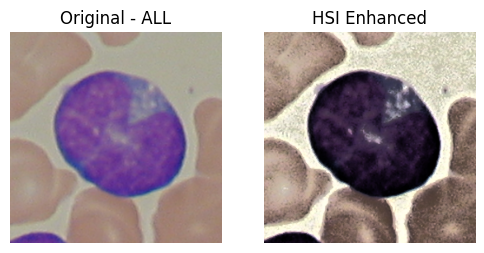

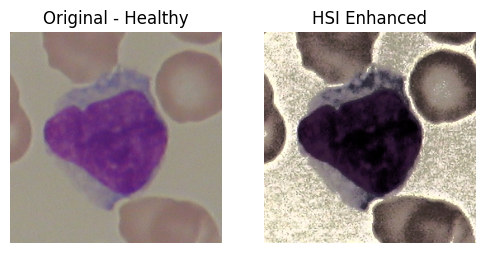

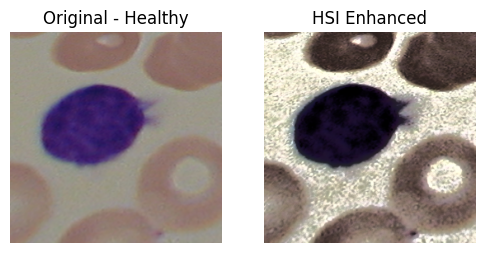

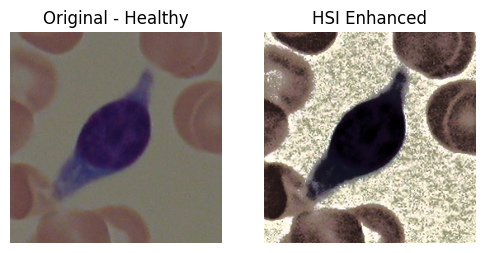

In [ ]:
# ==========================================
# 5. Visualize Sample Images Before/After HSI Enhancement
# ==========================================

sample_indices = random.sample(range(len(image_paths)), min(4, len(image_paths)))

for idx in sample_indices:
    img = Image.open(image_paths[idx]).convert("RGB")
    enhanced = hsi_contrast_enhancement(img)
    label_name = idx_to_class[labels[idx]]

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original - {label_name}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(enhanced)
    plt.title("HSI Enhanced")
    plt.axis("off")
    plt.show()


In [ ]:
# ==========================================
# 6. Stratified Train / Validation / Test Split
# ==========================================

# 70% Train, 15% Validation, 15% Test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Train:", len(train_paths), Counter(train_labels))
print("Validation:", len(val_paths), Counter(val_labels))
print("Test:", len(test_paths), Counter(test_labels))


Train: 3952 Counter({1: 1986, 0: 1966})
Validation: 847 Counter({1: 426, 0: 421})
Test: 848 Counter({1: 426, 0: 422})


In [ ]:
# ==========================================
# 7. PyTorch Dataset + Transforms
# ==========================================

APPLY_HSI = True   # Set to False if you want to disable HSI enhancement
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0    # Windows/Jupyter friendly

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class LeukemiaDataset(Dataset):
    def __init__(self, paths, labels, transform=None, apply_hsi=True):
        self.paths = paths
        self.labels = labels
        self.transform = transform
        self.apply_hsi = apply_hsi

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.apply_hsi:
            image = hsi_contrast_enhancement(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

train_dataset = LeukemiaDataset(train_paths, train_labels, train_transform, APPLY_HSI)
val_dataset = LeukemiaDataset(val_paths, val_labels, val_test_transform, APPLY_HSI)
test_dataset = LeukemiaDataset(test_paths, test_labels, val_test_transform, APPLY_HSI)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("DataLoaders are ready.")


DataLoaders are ready.


In [ ]:
# ==========================================
# 8. Class Weights for Balanced Training
# ==========================================

train_count = Counter(train_labels)
num_classes = len(class_to_idx)
class_weights = []

for i in range(num_classes):
    class_weights.append(len(train_labels) / (num_classes * train_count[i]))

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)


Class weights: tensor([1.0051, 0.9950])


In [ ]:
# ==========================================
# 9. Hybrid Model: EfficientNetV2-S + ConvNeXt-Tiny
# Feature Extraction + Feature Fusion + Classification
# ==========================================

class LeukemiaHybridModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # EfficientNetV2-S pretrained on ImageNet
        self.eff = models.efficientnet_v2_s(
            weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        )
        eff_out_features = self.eff.classifier[1].in_features
        self.eff.classifier = nn.Identity()  # feature extraction layer output

        # ConvNeXt-Tiny pretrained on ImageNet
        self.conv = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )
        conv_out_features = self.conv.classifier[2].in_features
        self.conv.classifier[2] = nn.Identity()  # feature extraction layer output

        # Freeze pretrained feature extractors in initial training
        for param in self.eff.parameters():
            param.requires_grad = False
        for param in self.conv.parameters():
            param.requires_grad = False

        # Feature Fusion Classification Head
        fused_features = eff_out_features + conv_out_features
        self.classifier = nn.Sequential(
            nn.Linear(fused_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        eff_features = self.eff(x)
        conv_features = self.conv(x)

        # Serial Feature Fusion / Feature Concatenation
        fused_features = torch.cat((eff_features, conv_features), dim=1)

        outputs = self.classifier(fused_features)
        return outputs

model = LeukemiaHybridModel(num_classes=num_classes).to(device)
print(model.__class__.__name__)


LeukemiaHybridModel


In [ ]:
# ==========================================
# 10. Training and Validation Functions
# ==========================================

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for images, labels_batch in loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


def train_model(model, train_loader, val_loader, optimizer, epochs=10, patience=4, save_path="best_leukemia_hybrid_model.pth"):
    best_val_loss = float("inf")
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = run_one_epoch(model, val_loader, optimizer=None)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print("  Best model saved.")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    print("Best Val Loss:", best_val_loss)
    print("Best Val Acc:", best_val_acc)
    return model


In [ ]:
# ==========================================
# 11. Initial Training Phase
# ==========================================

EPOCHS_INITIAL = 10

model = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    epochs=EPOCHS_INITIAL,
    patience=4,
    save_path="best_leukemia_hybrid_model.pth"
)


Epoch 01/10 | Train Loss: 0.1623, Train Acc: 0.9362 | Val Loss: 0.0421, Val Acc: 0.9870
  Best model saved.
Epoch 02/10 | Train Loss: 0.0762, Train Acc: 0.9719 | Val Loss: 0.0178, Val Acc: 0.9965
  Best model saved.
Epoch 03/10 | Train Loss: 0.0571, Train Acc: 0.9780 | Val Loss: 0.0153, Val Acc: 0.9976
  Best model saved.
Epoch 04/10 | Train Loss: 0.0513, Train Acc: 0.9790 | Val Loss: 0.0109, Val Acc: 0.9976
  Best model saved.
Epoch 05/10 | Train Loss: 0.0524, Train Acc: 0.9823 | Val Loss: 0.0101, Val Acc: 0.9976
  Best model saved.
Epoch 06/10 | Train Loss: 0.0508, Train Acc: 0.9810 | Val Loss: 0.0114, Val Acc: 0.9976
Epoch 07/10 | Train Loss: 0.0422, Train Acc: 0.9846 | Val Loss: 0.0058, Val Acc: 0.9988
  Best model saved.
Epoch 08/10 | Train Loss: 0.0390, Train Acc: 0.9873 | Val Loss: 0.0079, Val Acc: 0.9976
Epoch 09/10 | Train Loss: 0.0381, Train Acc: 0.9884 | Val Loss: 0.0029, Val Acc: 1.0000
  Best model saved.
Epoch 10/10 | Train Loss: 0.0383, Train Acc: 0.9871 | Val Loss: 0.00

In [ ]:
# ==========================================
# 12. Fine-Tuning Phase
# Unfreeze selected last layers of both pretrained models
# ==========================================

# Load best model before fine-tuning
model.load_state_dict(torch.load("best_leukemia_hybrid_model.pth", map_location=device))

# Unfreeze last blocks for fine-tuning
for param in model.eff.features[-2:].parameters():
    param.requires_grad = True

for param in model.conv.features[-2:].parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

EPOCHS_FINE_TUNE = 5

model = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    epochs=EPOCHS_FINE_TUNE,
    patience=3,
    save_path="best_leukemia_hybrid_model_finetuned.pth"
)


Epoch 01/5 | Train Loss: 0.0273, Train Acc: 0.9894 | Val Loss: 0.0017, Val Acc: 1.0000
  Best model saved.


KeyboardInterrupt: 

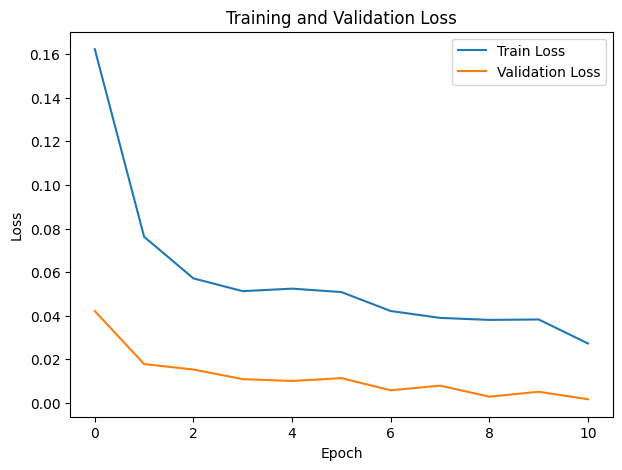

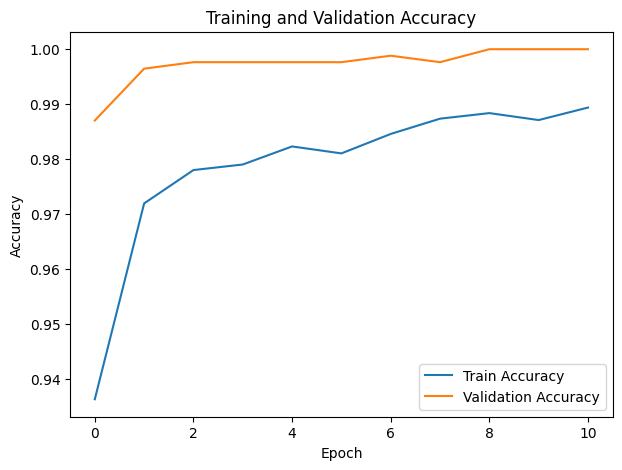

In [ ]:
# ==========================================
# 13. Plot Training Curves
# ==========================================

plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


In [ ]:
# ==========================================
# 14. Test Evaluation
# ==========================================

best_model_path = "best_leukemia_hybrid_model_finetuned.pth"
if not os.path.exists(best_model_path):
    best_model_path = "best_leukemia_hybrid_model.pth"

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_labels = []
all_preds = []
all_probs = []

test_loss = 0.0

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)

        test_loss += loss.item() * images.size(0)
        all_labels.extend(labels_batch.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

avg_test_loss = test_loss / len(test_dataset)
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs)

print("Test Loss:", round(avg_test_loss, 4))
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1-score:", round(f1 * 100, 2), "%")
print("ROC-AUC:", round(roc_auc * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=[idx_to_class[0], idx_to_class[1]]))


Test Loss: 0.0049
Accuracy: 99.88 %
Precision: 99.77 %
Recall: 100.0 %
F1-score: 99.88 %
ROC-AUC: 100.0 %

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       422
         ALL       1.00      1.00      1.00       426

    accuracy                           1.00       848
   macro avg       1.00      1.00      1.00       848
weighted avg       1.00      1.00      1.00       848



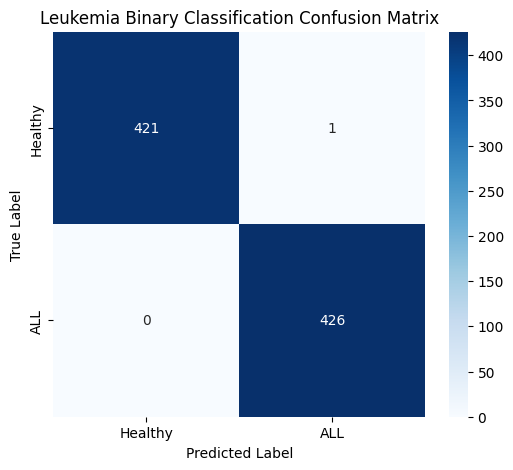

In [ ]:
# ==========================================
# 15. Confusion Matrix
# ==========================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[idx_to_class[0], idx_to_class[1]],
    yticklabels=[idx_to_class[0], idx_to_class[1]]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Leukemia Binary Classification Confusion Matrix")
plt.show()


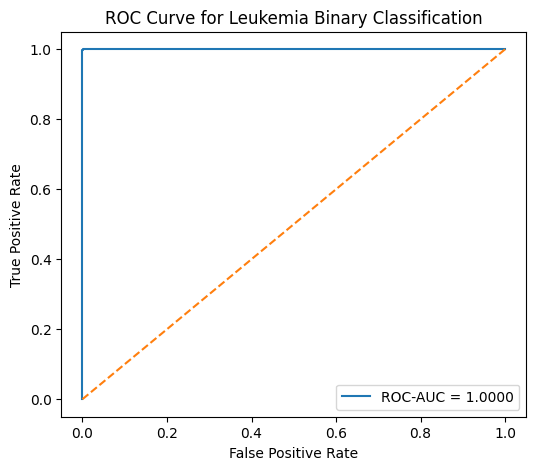

In [ ]:
# ==========================================
# 16. ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Leukemia Binary Classification")
plt.legend()
plt.show()


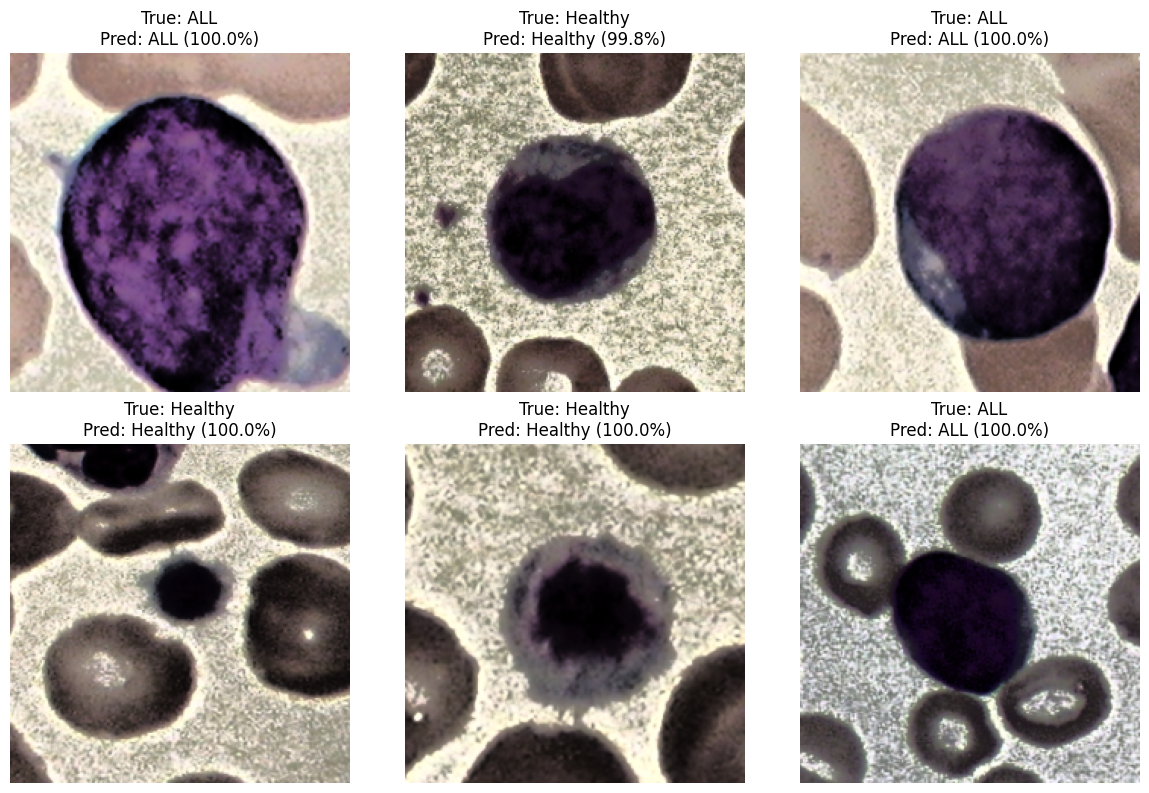

In [ ]:
# ==========================================
# 17. Show Sample Predictions
# ==========================================

def unnormalize(tensor_img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img.permute(1, 2, 0).numpy()

model.eval()
images, labels_batch = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(outputs, dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(min(6, images.size(0))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(unnormalize(images[i]))
    true_name = idx_to_class[int(labels_batch[i])]
    pred_name = idx_to_class[int(preds[i])]
    confidence = probs[i, preds[i]].item() * 100
    plt.title(f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Notes for the Report

- Deep feature extraction was performed by removing the final classification layers of EfficientNetV2-S and ConvNeXt-Tiny and replacing them with identity mappings.
- The extracted feature vectors were concatenated using serial feature fusion.
- The fused representation was passed to fully connected classification layers for binary classification between Healthy and ALL classes.
- HSI preprocessing enhances the intensity channel while preserving hue and saturation information.